### DAS Data

In [1]:
import sys
import numpy as np
from pathlib import Path

sys.path.append('..')

from src.plots import plot_das_wavefield, plot_das_psd, plot_das_psd_2d, plot_das_traces

In [2]:
# 1. Define paths 
urban_dir = Path('..') / 'data' / 'raw_urban' / '20210901'

# Grab the first processed urban files
urban_files = sorted(urban_dir.glob('*.npz'))
das_paths = urban_files[:1]

if not das_paths:
    raise FileNotFoundError(f"No _urban.npz files found in {urban_dir}")

for p in das_paths:
    print(f"Found: {p.name}")

Found: 20210901_000000.npz


In [3]:
# 2. Load the first file
das_data = np.load(das_paths[0])

print("\nKeys inside .npz file:")
for key in das_data:
    print(f' - {key}')


Keys inside .npz file:
 - data
 - dt
 - t_axis
 - x_axis
 - event_files
 - event_time
 - pre_time
 - post_time
 - dx


In [4]:
# 3. Extract data and natively saved metadata
raw_array = das_data['data']
dt = float(das_data['dt'])           
dx = float(das_data['dx'])      
fs = 1.0 / dt

N = raw_array.shape[1]               # Number of time samples
num_channels = raw_array.shape[0]    # Number of channels

In [5]:
# 4. PREPROCESSING: Zero-mean the data (DC Offset Removal)
das_array = raw_array - np.mean(raw_array, axis=1, keepdims=True)

# 5. Create t_axis and x_axis ON THE FLY
t_axis = np.arange(N) * dt             # Time in seconds
x_axis = np.arange(num_channels) * dx  

print(f"\nDAS array shape: {das_array.shape} (Channels x Time)")
print(f"Time axis shape: {t_axis.shape}")
print(f"Channel axis shape: {x_axis.shape}")
print(f"Total duration: {(N * dt) / 60:.2f} minutes")
print(f"Total bridge length: {x_axis[-1]:.2f} meters")


DAS array shape: (350, 157500) (Channels x Time)
Time axis shape: (157500,)
Channel axis shape: (350,)
Total duration: 10.50 minutes
Total bridge length: 2847.84 meters


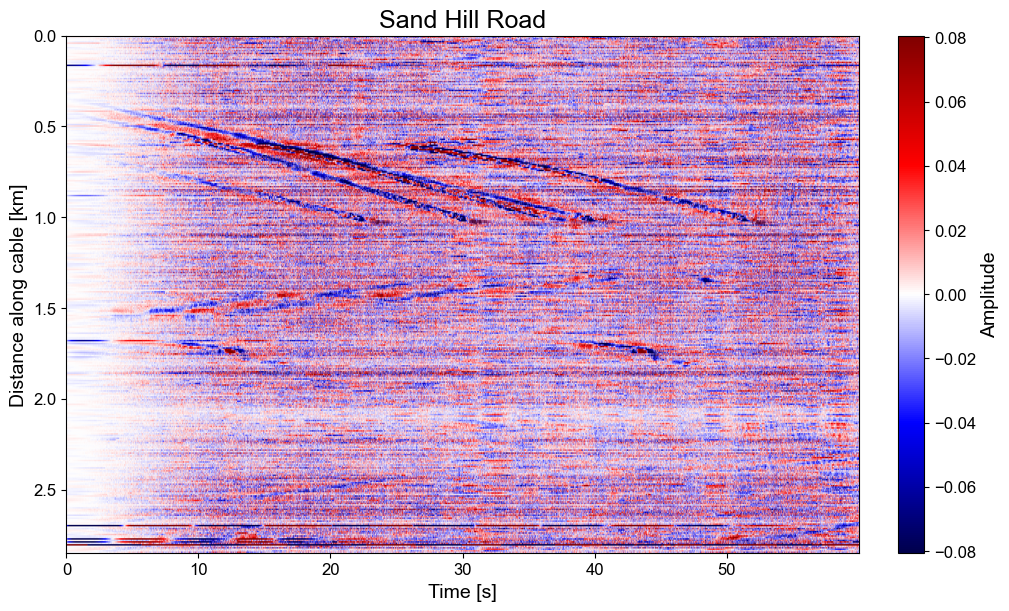

In [6]:
plot_das_wavefield(
    das_array,
    fs=fs,
    dx=dx,
    start_sec=0.0,
    duration_sec=60.0,     
    start_chan=None, 
    end_chan=None, 
    pclip=98,            
    title="Sand Hill Road", 
    figsize=(10, 6)
)

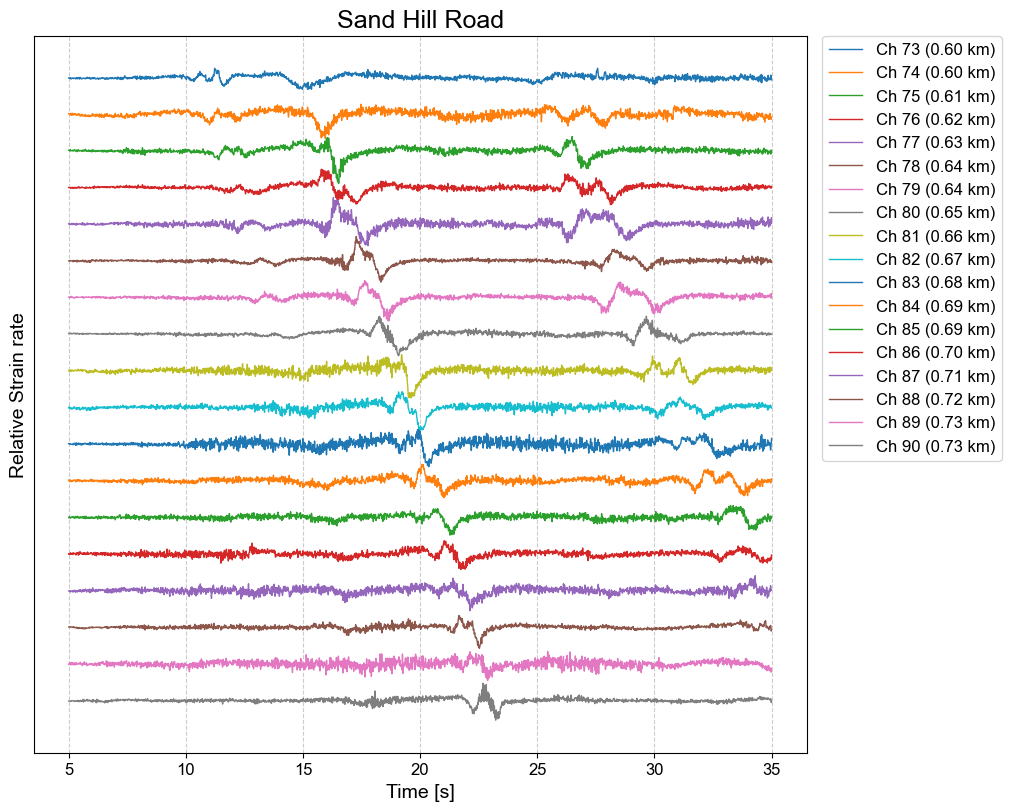

In [ ]:
step_size = 1
ch_500m = int(600 / dx)
ch_1000m = int(750 / dx)
channels_to_plot = np.arange(ch_500m, ch_1000m, step_size)

# Plot the 1D Traces
plot_das_traces(
    data=das_array,
    fs=fs,
    dx=dx,
    channels=channels_to_plot,   # Pass the specific list of channels
    start_sec=5.0,               # Match wavefield start time
    duration_sec=30.0,           # Match wavefield duration
    spacing_factor=10.0,         # Adjust this if lines are overlapping too much or are too far apart
    clabel='Strain rate',
    figsize=(10, 8),             # Made slightly taller (8) to comfortably fit the stacked traces
    title="Sand Hill Road"
)

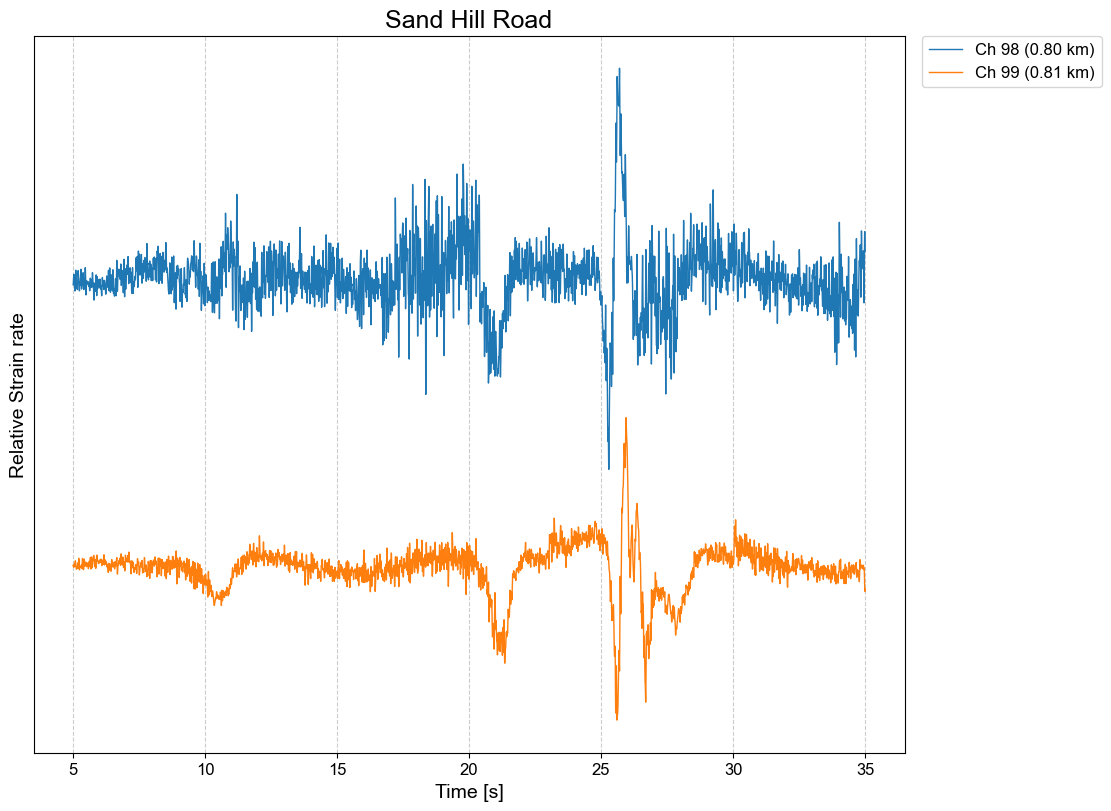

In [ ]:
step_size = 1
ch_800m = int(800 / dx)
ch_820m = int(820 / dx)
channels_to_plot = np.arange(ch_800m, ch_820m, step_size)
# 2. Plot the 1D Traces
plot_das_traces(
    data=das_array,
    fs=fs,
    dx=dx,
    channels=channels_to_plot,   # Pass the specific list of channels
    start_sec=5.0,               # Match wavefield start time
    duration_sec=30.0,           # Match wavefield duration
    spacing_factor=10.0,         # Adjust this if lines are overlapping too much or are too far apart
    clabel='Strain rate',
    figsize=(11, 8),             # Made slightly taller (8) to comfortably fit the stacked traces
    title="Sand Hill Road"
)

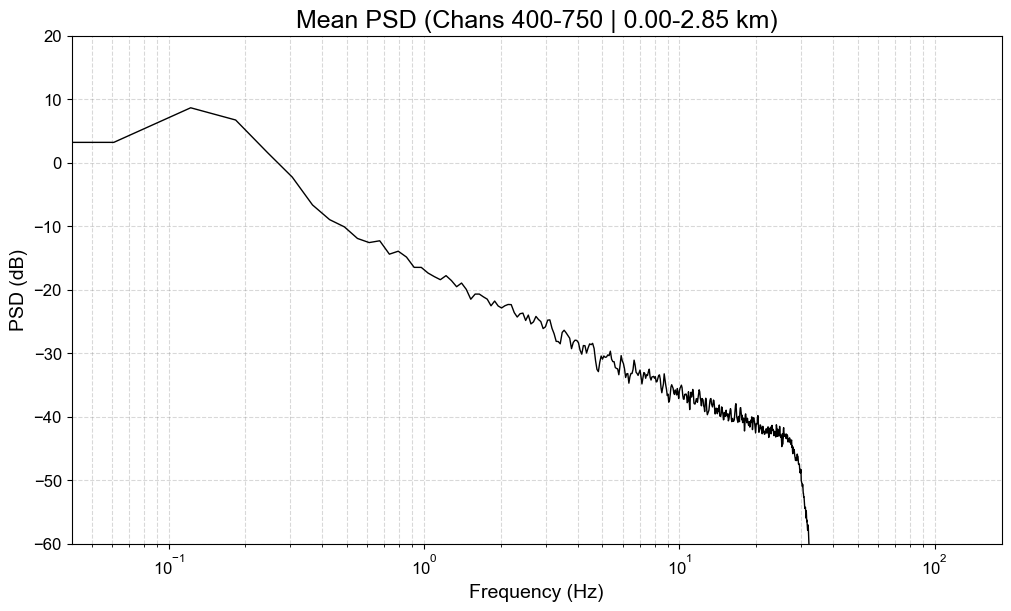

In [9]:
plot_das_psd(
    data=das_array,
    fs=fs,
    dx=dx,
    start_chan=0,
    end_chan=None,
    nperseg=4096,           
    flim=None,       
    psd_ylim=(-60, 20),              
    xscale="log",        
    ylabel="PSD (dB)",
    figsize=(10, 6), 
    title="Mean PSD (Chans 400-750 | 0.00-2.85 km)"
)

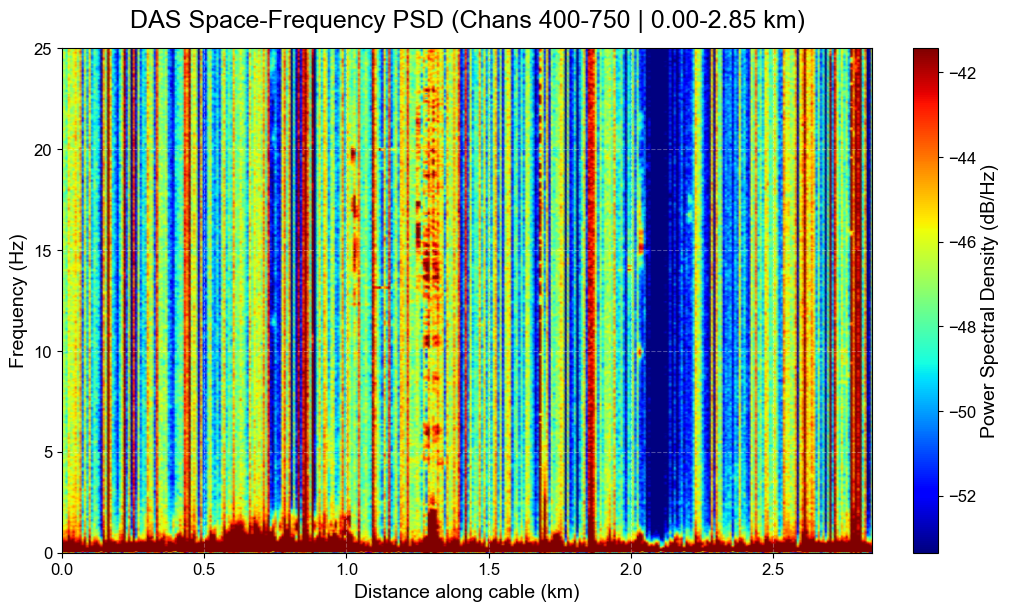

In [10]:
plot_das_psd_2d(
    data=das_array,
    fs=fs,
    dx=dx,
    start_chan=0,
    end_chan=None,
    nperseg=4096,     
    flim=(0, 25),                            
    figsize=(10, 6), 
    title="DAS Space-Frequency PSD (Chans 400-750 | 0.00-2.85 km)"
)